# Watch a camera for *any* event the user describes

The user types what they want to be told about — *"the cat got on the table"*,
*"the washing machine finished"*, *"the child woke up"* — and nothing in the code changes.
Working on separate frames here; a live stream is a later problem.

**The split that makes it work:**

| stage | who | how often |
|---|---|---|
| is the event's **end state** true in this one frame? | model, vision | once per **frame**, cached |
| did the event **happen** between two frames? | plain Python | free |

Stage 2 is `(not state[before]) and state[after]`.

The model never sees two frames and never reasons about time. Asked about a pair directly,
`qwen3.6-27b` answers `true` whenever the thing is present in *either* frame — it ignores the
direction of time (3/5 on the cases below). Asked about one frame at a time it is right every
time, and the time logic becomes code that cannot be wrong. It is also cheaper: one request
per **frame** instead of one per **pair**.

Nothing below is specific to cats: the event text is a variable, the JSON schema is
`{"state_now": bool, "evidence": str}`, and the cat footage is just the sample we happen to have.

Provider: Groq, `qwen/qwen3.6-27b`, OpenAI-compatible HTTP, JSON responses.

In [25]:
import base64
import json
import re
import sys
from io import BytesIO
from pathlib import Path
from time import perf_counter, sleep

import requests
from IPython.display import HTML, display
from PIL import Image

DATA_DIR = Path("data") if Path("data").is_dir() else Path("../data")
sys.path.insert(0, str(DATA_DIR.resolve().parent))
from src.config import GROQ_API_KEY  # noqa: E402

MODEL = "qwen/qwen3.6-27b"
URL = "https://api.groq.com/openai/v1/chat/completions"
MAX_WIDTH = 640  # camera gives ~2000px; the model downscales anyway
# ---- the only thing a user writes ----------------------------------------
USER_EVENT = "the cat got onto the table (a cat on a chair or on the floor does not count)"
# --------------------------------------------------------------------------

# Base prompt: same text for every event. It asks about the END STATE of the user's event
# in ONE frame, never about the event itself — the event needs two frames and belongs to code.
BASE_PROMPT = (
    "You look at a single still frame from a fixed security camera.\n"
    "The user is waiting for this to happen:\n"
    "  {event}\n"
    "Ignore whether it *just* happened — you cannot know, you see one frame.\n"
    "Answer only this: in THIS frame, is the end state of that event already true?\n"
    "If the frame is too dark or unclear to tell, answer false.\n"
    'Reply with JSON only: {{"state_now": true|false, "evidence": "<a few words on what you see>"}}'
)

# json_object works on every Groq model; strict json_schema is limited to gpt-oss and qwen3.8-27b,
# and qwen3.6-27b is the one that actually reads this footage.
RESPONSE_FORMAT = {"type": "json_object"}


def prompt_for(event: str) -> str:
    return BASE_PROMPT.format(event=event)

FRAMES = ["1.png", "2.png", "3.png"]
# hand-labelled ground truth for USER_EVENT above: is its end state true in this frame?
TRUTH = {"1.png": False, "2.png": False, "3.png": True}

print("key loaded:", bool(GROQ_API_KEY), "| frames:", [f.name for f in sorted(DATA_DIR.glob("*.png"))])

key loaded: True | frames: ['1.png', '2.png', '3.png']


In [26]:
def load(name: str, width: int = MAX_WIDTH) -> Image.Image:
    """Camera PNG -> grayscale, downscaled."""
    image = Image.open(DATA_DIR / name).convert("L")
    return image.resize((width, round(image.height * width / image.width)))


def jpeg(image: Image.Image, quality: int = 85) -> bytes:
    buffer = BytesIO()
    image.save(buffer, "JPEG", quality=quality)
    return buffer.getvalue()


def thumbnail(name: str, width: int = 260) -> str:
    """Small inline preview for the tables below."""
    data = base64.b64encode(jpeg(load(name, width), quality=70)).decode()
    return f'<img src="data:image/jpeg;base64,{data}" width="{width}">'


def detect(name: str, cache: dict, event: str = None) -> dict:
    """Is the end state of `event` true in frame `name`? One request per (frame, event).

    Returns {"state", "evidence", "request", "waited", ...} — request time and rate-limit
    waiting are kept apart on purpose: only the first says anything about the model.
    """
    event = event or USER_EVENT
    key = (name, event)
    if key in cache:
        return cache[key]

    question = prompt_for(event)

    payload = {
        "model": MODEL,
        "temperature": 0,
        "max_completion_tokens": 64,
        "response_format": RESPONSE_FORMAT,  # valid JSON guaranteed, no regex fishing
        "reasoning_effort": "none",  # otherwise the answer is buried in <think>
        "messages": [{"role": "user", "content": [
            {"type": "text", "text": question},
            {"type": "image_url", "image_url": {
                "url": "data:image/jpeg;base64," + base64.b64encode(jpeg(load(name))).decode()}},
        ]}],
    }

    waited = 0.0
    for _ in range(4):
        call_started = perf_counter()
        response = requests.post(URL, headers={"Authorization": f"Bearer {GROQ_API_KEY}"}, json=payload, timeout=60)
        # free tier: 7000 input tokens/min and an image costs 2048 -> ~3 requests/min
        if response.status_code == 429:
            pause = float(response.headers.get("retry-after", 5)) + 1
            sleep(pause)
            waited += perf_counter() - call_started
            continue
        response.raise_for_status()
        body = response.json()
        choice = body["choices"][0]
        raw = choice["message"].get("content") or ""
        try:
            parsed = json.loads(raw)
            answer, evidence = bool(parsed["state_now"]), str(parsed.get("evidence", ""))
        except (json.JSONDecodeError, KeyError, TypeError):
            # json_object guarantees valid JSON, not the schema: keep a regex net
            found = re.findall(r"true|false", raw.lower().split("</think>")[-1])
            answer, evidence = ((found[-1] == "true") if found else None), "<unparsed>"
        cache[key] = {
            "state": answer,
            "evidence": evidence,
            "event": event,
            "question": question,
            "request": round(perf_counter() - call_started, 2),
            "waited": round(waited, 2),
            # everything the model actually sent back, for the inspection cell below
            "raw": raw,
            "reasoning": choice["message"].get("reasoning") or "",
            "finish_reason": choice.get("finish_reason"),
            "usage": body.get("usage", {}),
            "sent_bytes": len(payload["messages"][0]["content"][1]["image_url"]["url"]),
        }
        return cache[key]

    cache[key] = {"state": None, "evidence": "", "event": event, "question": question,
                  "request": 0.0, "waited": round(waited, 2), "raw": "<rate limited>",
                  "reasoning": "", "finish_reason": None, "usage": {}, "sent_bytes": 0}
    return cache[key]

user event: the cat got onto the table (a cat on a chair or on the floor does not count) 



"1.pngstate_now: False ✓label: Falseevidence: «The cat is sitting on a chair, not on the table.»request 0.51s","2.pngstate_now: False ✓label: Falseevidence: «The cat is standing on a chair, not on the table.»request 0.43s",3.pngstate_now: True ✓label: Trueevidence: «A cat is clearly visible standing on top of the table.»request 0.47s + 10.14s waiting on rate limit

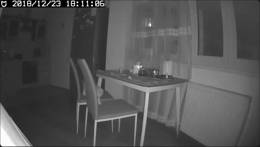
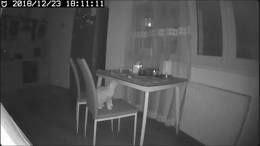
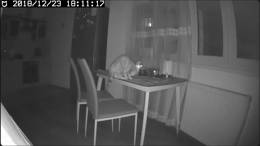

In [27]:
# Step 1 — ask about the end state of USER_EVENT, one frame at a time.
print("user event:", USER_EVENT, "\n")
state, timing = {}, {}
cache: dict = {}
step1_started = perf_counter()
for name in FRAMES:
    result = detect(name, cache)
    state[name] = result["state"]
    timing[name] = result
step1_wall = round(perf_counter() - step1_started, 2)
request_time = round(sum(t["request"] for t in timing.values()), 2)
wait_time = round(sum(t["waited"] for t in timing.values()), 2)

cells = ""
for name in FRAMES:
    correct = state[name] == TRUTH[name]
    colour = "#2e7d32" if correct else "#c62828"  # green = matches the label, not "= False"
    waited = timing[name]["waited"]
    cells += (
        f"<td style='text-align:center;padding:8px'>{thumbnail(name)}<br>"
        f"<b>{name}</b><br>"
        f"state_now: <b>{state[name]}</b> "
        f"<span style='color:{colour};font-size:18px'>{'✓' if correct else '✗'}</span><br>"
        f"<span style='color:#888'>label: {TRUTH[name]}</span><br>"
        f"<span style='color:#888'>evidence: &laquo;{timing[name]['evidence']}&raquo;</span><br>"
        f"<span style='color:#888'>request {timing[name]['request']}s"
        + (f" + {waited}s waiting on rate limit" if waited else "")
        + "</span></td>"
    )

hits = sum(state[n] == TRUTH[n] for n in FRAMES)
fastest = min(t["request"] for t in timing.values())
slowest = max(t["request"] for t in timing.values())
display(HTML(
    f"<table><tr>{cells}</tr></table>"
    f"<p>per-frame detection: <b>{hits}/{len(FRAMES)}</b> match the label "
    f"(<span style='color:#2e7d32'>✓</span> = model agrees with the label)<br>"
    f"model time: <b>{request_time}s</b> for {len(FRAMES)} requests "
    f"(fastest {fastest}s, slowest {slowest}s)<br>"
    f"rate-limit waiting: <b>{wait_time}s</b> · wall clock: {step1_wall}s<br>"
    f"<span style='color:#888'>free tier allows 7000 input tokens/min and an image costs 2048, "
    f"so ~3 requests/min — the waiting is the plan's, not the model's</span></p>"
))

before,,after,event,expected,,case,time
,→,,False,False,✓,cat only reaches the chair,12.0 µs
,→,,True,True,✓,chair -> table: the event,2.4 µs
,→,,True,True,✓,floor -> table: the event,3.5 µs
,→,,False,False,✓,nothing changed,3.0 µs
,→,,False,False,✓,cat left the table: wrong direction,2.0 µs

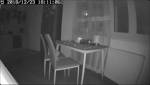
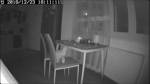
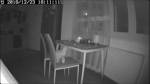
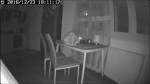
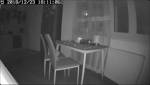
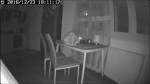
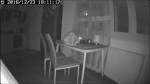
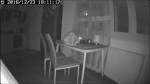
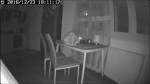
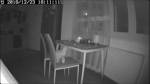

In [29]:
# Step 2 — the event itself. No API calls here: pure logic over cached frame states.
CASES = [
    ("1.png", "2.png", False, "cat only reaches the chair"),
    ("2.png", "3.png", True, "chair -> table: the event"),
    ("1.png", "3.png", True, "floor -> table: the event"),
    ("3.png", "3.png", False, "nothing changed"),
    ("3.png", "2.png", False, "cat left the table: wrong direction"),
]


def happened(before: str, after: str) -> bool:
    """The event = absent in the earlier frame, present in the later one."""
    return (not state[before]) and state[after]


rows = ""
passed = 0
case_micros = []
for before, after, expected, note in CASES:
    started = perf_counter()
    got = happened(before, after)
    micros = round((perf_counter() - started) * 1_000_000, 1)
    case_micros.append(micros)
    ok = got == expected
    passed += ok
    rows += (
        f"<tr>"
        f"<td style='padding:6px'>{thumbnail(before, 150)}</td>"
        f"<td style='padding:6px;font-size:22px'>&rarr;</td>"
        f"<td style='padding:6px'>{thumbnail(after, 150)}</td>"
        f"<td style='padding:10px'><b>{got}</b></td>"
        f"<td style='padding:10px;color:#888'>{expected}</td>"
        f"<td style='padding:10px;font-size:20px;color:{'#2e7d32' if ok else '#c62828'}'>{'✓' if ok else '✗'}</td>"
        f"<td style='padding:10px;color:#888'>{note}</td>"
        f"<td style='padding:10px;color:#888'>{micros} µs</td>"
        f"</tr>"
    )

logic_time = round(sum(case_micros), 1)
display(HTML(
    "<table><tr>"
    "<th>before</th><th></th><th>after</th><th>event</th><th>expected</th><th></th><th>case</th><th>time</th>"
    f"</tr>{rows}</table>"
    f"<h3 style='color:{'#2e7d32' if passed == len(CASES) else '#c62828'}'>{passed}/{len(CASES)} cases correct — 0 extra API calls</h3>"
    f"<p>time budget for all {len(CASES)} pairs:<br>"
    f"&nbsp;&nbsp;model, {len(FRAMES)} frames: <b>{request_time}s</b> (fastest request {fastest}s)<br>"
    f"&nbsp;&nbsp;event logic, {len(CASES)} pairs: <b>{logic_time} µs</b><br>"
    f"&nbsp;&nbsp;rate-limit waiting: {wait_time}s (free tier only)<br>"
    f"&nbsp;&nbsp;total wall clock: <b>{step1_wall}s</b><br>"
    f"<span style='color:#888'>asking the model per pair instead would cost "
    f"{len(CASES)} requests instead of {len(FRAMES)}, and it scored 3/5 that way</span></p>"
))
assert passed == len(CASES), "event logic or frame detection regressed"

## What happens inside one call

Nothing below hits the API — it replays what was already captured per frame:
what was sent, what came back verbatim, and what it cost.

prompt tokens per frame: [916, 916, 916]
note: usage reports ~900 tokens, but the rate limiter charges more — its 429 message says 'Requested 2237' for the same call, matching the documented flat 2048 per image. Billing and throttling count differently.


1.png 640x361 grayscale JPEG 29 KB as base64 data URI,"SENT — base prompt with the user's event pasted in You look at a single still frame from a fixed security camera. The user is waiting for this to happen: the cat got onto the table (a cat on a chair or on the floor does not count) Ignore whether it *just* happened — you cannot know, you see one frame. Answer only this: in THIS frame, is the end state of that event already true? If the frame is too dark or unclear to tell, answer false. Reply with JSON only: {""state_now"": true|false, ""evidence"": ""<a few words on what you see>""} RECEIVED — message.content, verbatim { ""state_now"": false, ""evidence"": ""The cat is sitting on a chair, not on the table."" } PARSED — json.loads, no regex state_now=False, evidence='The cat is sitting on a chair, not on the table.' finish_reason: stop · tokens in/out: 916/32 · request: 0.51s"
2.png 640x359 grayscale JPEG 29 KB as base64 data URI,"SENT — base prompt with the user's event pasted in You look at a single still frame from a fixed security camera. The user is waiting for this to happen: the cat got onto the table (a cat on a chair or on the floor does not count) Ignore whether it *just* happened — you cannot know, you see one frame. Answer only this: in THIS frame, is the end state of that event already true? If the frame is too dark or unclear to tell, answer false. Reply with JSON only: {""state_now"": true|false, ""evidence"": ""<a few words on what you see>""} RECEIVED — message.content, verbatim { ""state_now"": false, ""evidence"": ""The cat is standing on a chair, not on the table."" } PARSED — json.loads, no regex state_now=False, evidence='The cat is standing on a chair, not on the table.' finish_reason: stop · tokens in/out: 916/37 · request: 0.43s"
3.png 640x359 grayscale JPEG 30 KB as base64 data URI,"SENT — base prompt with the user's event pasted in You look at a single still frame from a fixed security camera. The user is waiting for this to happen: the cat got onto the table (a cat on a chair or on the floor does not count) Ignore whether it *just* happened — you cannot know, you see one frame. Answer only this: in THIS frame, is the end state of that event already true? If the frame is too dark or unclear to tell, answer false. Reply with JSON only: {""state_now"": true|false, ""evidence"": ""<a few words on what you see>""} RECEIVED — message.content, verbatim { ""state_now"": true, ""evidence"": ""A cat is clearly visible standing on top of the table."" } PARSED — json.loads, no regex state_now=True, evidence='A cat is clearly visible standing on top of the table.' finish_reason: stop · tokens in/out: 916/31 · request: 0.47s · waited 10.14s on the rate limit"

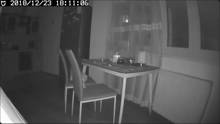
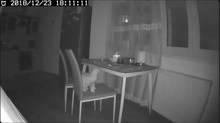
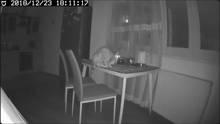

In [31]:
def esc(text: str) -> str:
    return text.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")


blocks = ""
for name in FRAMES:
    t = timing[name]
    image = load(name)
    usage = t["usage"]
    parsed = f'state_now={t["state"]}, evidence={t["evidence"]!r}'
    blocks += f"""
    <div style="border:1px solid #ddd;border-radius:6px;padding:12px;margin-bottom:14px">
      <table><tr>
        <td style="vertical-align:top;padding-right:14px">{thumbnail(name, 220)}<br>
          <b>{name}</b><br>
          <span style="color:#888">{image.width}x{image.height} grayscale JPEG<br>
          {t['sent_bytes'] // 1024} KB as base64 data URI</span>
        </td>
        <td style="vertical-align:top">
          <div style="color:#888">SENT — base prompt with the user's event pasted in</div>
          <pre style="background:#f7f7f7;padding:8px;white-space:pre-wrap;margin:4px 0">{esc(t['question'])}</pre>
          <div style="color:#888">RECEIVED — message.content, verbatim</div>
          <pre style="background:#f0f7f0;padding:8px;white-space:pre-wrap;margin:4px 0">{esc(t['raw']) or '(empty)'}</pre>
          <div style="color:#888">PARSED — json.loads, no regex</div>
          <pre style="background:#f7f7f7;padding:8px;margin:4px 0">{esc(parsed)}</pre>
          <div style="color:#888">
            finish_reason: <b>{t['finish_reason']}</b> ·
            tokens in/out: <b>{usage.get('prompt_tokens')}/{usage.get('completion_tokens')}</b> ·
            request: <b>{t['request']}s</b>{f" · waited {t['waited']}s on the rate limit" if t['waited'] else ""}
            {"<br>reasoning field: " + esc(t['reasoning'][:200]) if t['reasoning'] else ""}
          </div>
        </td>
      </tr></table>
    </div>"""

display(HTML(blocks))
print("prompt tokens per frame:", [t["usage"].get("prompt_tokens") for t in timing.values()])
print("note: usage reports ~900 tokens, but the rate limiter charges more — its 429 message says",
      "'Requested 2237' for the same call, matching the documented flat 2048 per image.",
      "Billing and throttling count differently.")